# Customer Churn Prediction — EDA & Machine Learning
Data cleaning, exploratory analysis, feature engineering, and churn prediction using Logistic Regression and Decision Tree models.

## 1. Load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

df = pd.read_csv("data/telco_churn_raw.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 16)


## 2. Data cleaning

In [ ]:
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

# customers with 0 tenure have no TotalCharges yet -> fill with MonthlyCharges
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])
df_model = df.drop(columns=["customerID"])
print("\nCleaned shape:", df_model.shape)


Missing values:
 TotalCharges    277
dtype: int64

Cleaned shape: (7043, 15)


## 3. Churn distribution

Churn
No     72.3
Yes    27.7
Name: proportion, dtype: float64


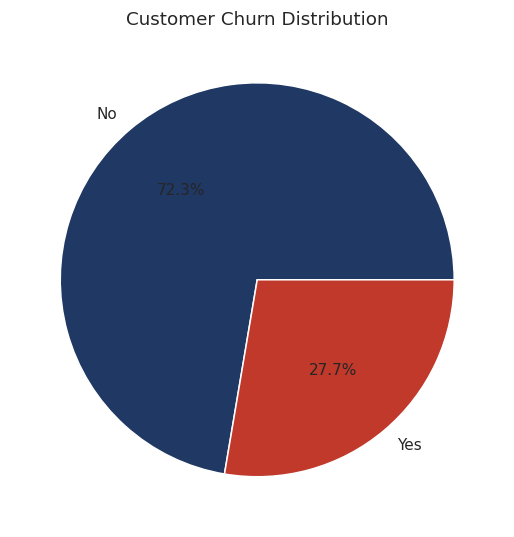

In [ ]:
churn_rate = df["Churn"].value_counts(normalize=True).mul(100).round(1)
print(churn_rate)

plt.figure(figsize=(5,5))
df["Churn"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["#1F3864","#C0392B"])
plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 4. Churn by contract type

Contract
Month-to-month    40.1
One year          17.0
Two year           8.5
Name: Churn, dtype: float64


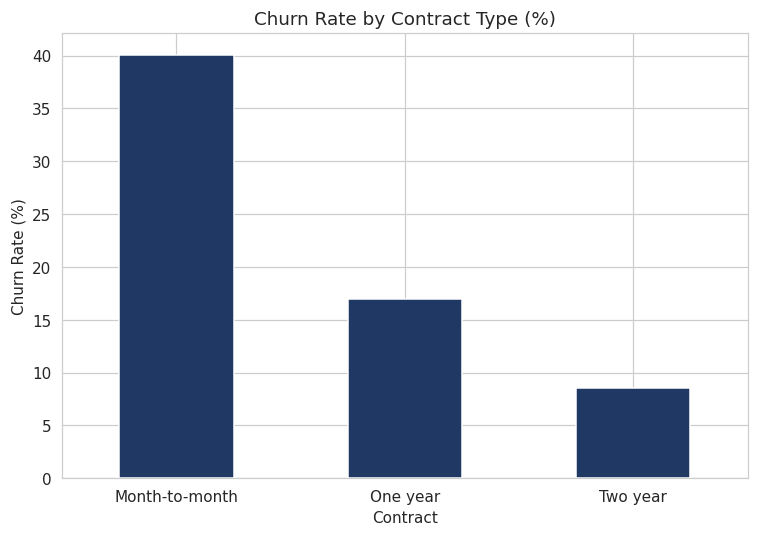

In [ ]:
contract_churn = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(1)
print(contract_churn)

plt.figure(figsize=(7,5))
contract_churn.sort_values(ascending=False).plot(kind="bar", color="#1F3864")
plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** Month-to-month customers churn at more than 3x the rate of two-year contract customers — the single strongest churn driver.

## 5. Monthly charges vs churn

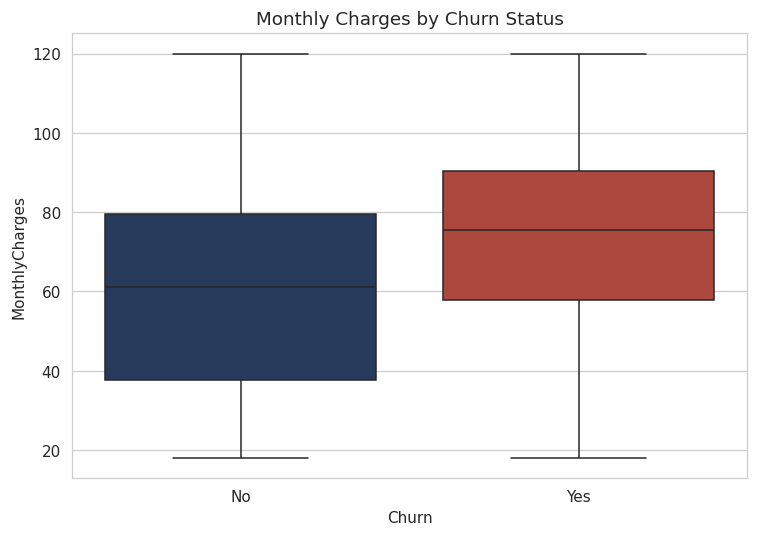

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#1F3864","#C0392B"])
plt.title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.show()


## 6. Tenure distribution by churn

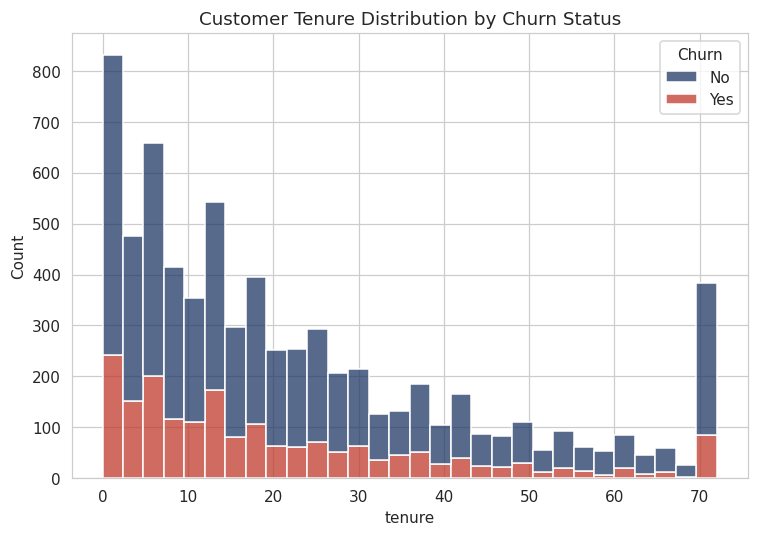

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack",
             palette=["#1F3864","#C0392B"])
plt.title("Customer Tenure Distribution by Churn Status")
plt.tight_layout()
plt.show()


## 7. Feature engineering & preprocessing

In [ ]:
target = (df_model["Churn"] == "Yes").astype(int)
X = df_model.drop(columns=["Churn"])

cat_cols = X.select_dtypes(include="object").columns
for c in cat_cols:
    X[c] = LabelEncoder().fit_transform(X[c])

X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.2, random_state=42, stratify=target
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (5634, 14)  Test size: (1409, 14)


## 8. Logistic Regression model

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_s, y_train)
pred_lr = log_reg.predict(X_test_s)
proba_lr = log_reg.predict_proba(X_test_s)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, pred_lr), 3))
print("AUC-ROC :", round(roc_auc_score(y_test, proba_lr), 3))
print(classification_report(y_test, pred_lr))


Accuracy: 0.759
AUC-ROC : 0.771
              precision    recall  f1-score   support

           0       0.78      0.92      0.85      1019
           1       0.62      0.33      0.43       390

    accuracy                           0.76      1409
   macro avg       0.70      0.63      0.64      1409
weighted avg       0.74      0.76      0.73      1409



## 9. Decision Tree model

In [ ]:
tree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=40, random_state=42)
tree.fit(X_train, y_train)
pred_dt = tree.predict(X_test)
proba_dt = tree.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, pred_dt), 3))
print("AUC-ROC :", round(roc_auc_score(y_test, proba_dt), 3))


Accuracy: 0.757
AUC-ROC : 0.76


## 10. Feature importance (top churn drivers)

Contract          0.456973
MonthlyCharges    0.307232
TechSupport       0.136015
tenure            0.032039
TotalCharges      0.023402
dtype: float64


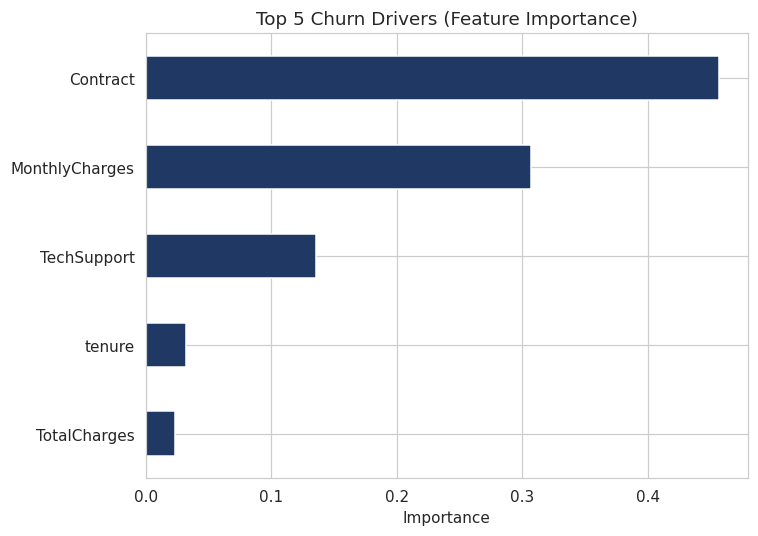

In [ ]:
importances = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(5))

plt.figure(figsize=(7,5))
importances.head(5).plot(kind="barh", color="#1F3864")
plt.title("Top 5 Churn Drivers (Feature Importance)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 11. Confusion matrix

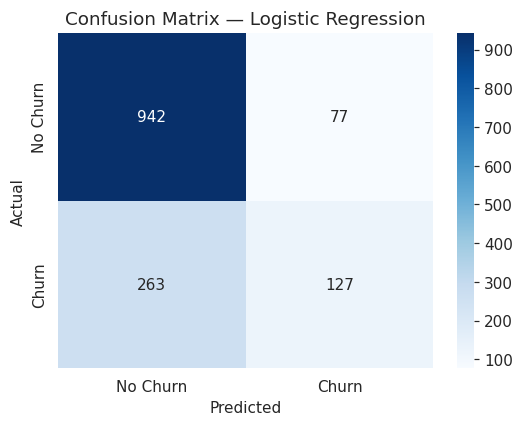

In [ ]:
cm = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


## Key Takeaways
- Contract type is by far the strongest churn driver, followed by monthly charges and lack of tech support.
- Month-to-month customers churn at roughly 4x the rate of two-year contract customers.
- Logistic Regression achieved ~76% accuracy / 0.77 AUC-ROC on this synthetic dataset; results will vary with the real Telco dataset and further feature engineering (e.g. tenure buckets, interaction terms) can push this higher.
- Retention efforts should prioritize month-to-month, high-monthly-charge customers with no tech support — the clearest at-risk segment.